In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import squidpy as sq
import torch
import scipy as sp
import sys
sys.path.append("../../")
import steamboat as sf
import steamboat.tools

import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['mathtext.fontset'] = 'dejavuserif'
matplotlib.rcParams['font.family'] = 'arial'
matplotlib.rcParams["legend.handletextpad"] = 0.
matplotlib.rcParams["legend.labelspacing"] = .3
pltkw = dict(bbox_inches='tight', transparent=True)

c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\spatialdata\_core\query\relational_query.py:530: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\spatialdata\_core\query\relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = parti

In [2]:
adata = sc.read_h5ad("../data/Ex5_slide_tags_human_tonsil/HumanTonsil_2000.h5ad")

In [3]:
adata.obs['global'] = 0
adatas = sf.prep_adatas([adata], norm=False, log1p=False, n_neighs=8)
dataset = sf.make_dataset(adatas, sparse_graph=True, regional_obs=['global'])

  0%|          | 0/1 [00:00<?, ?it/s]

Using None to mask variables. Explicitly specify `mask_var=False` to use all genes.
Using ['global'] as regional annotations.


  0%|          | 0/1 [00:00<?, ?it/s]

In [4]:
adata

AnnData object with n_obs × n_vars = 5778 × 2000
    obs: 'biosample_id', 'donor_id', 'species', 'species__ontology_label', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'sex', 'cluster', 'global'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cluster_colors', 'hvg', 'neighbors', 'pca', 'umap', 'spatial_neighbors'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances'

In [5]:
device = 'cuda'
sf.set_random_seed(0)
model = sf.Steamboat(adata.var_names.tolist(), n_heads=60, n_scales=3)
model = model.to(device)

In [6]:
# model.fit(dataset.to(device), entry_masking_rate=0.1, feature_masking_rate=0.1,
#             max_epoch=10000, 
#             loss_fun=torch.nn.MSELoss(reduction='sum'),
#             opt=torch.optim.Adam, opt_args=dict(lr=0.1), stop_eps=2e-5, report_per=1000, stop_tol=250, device=device)

# torch.save(model.state_dict(), 'saved_models/tonsil.pth')

# [2025-10-02 12:25:00,171::train::INFO] Epoch 1: train_loss 393.33020
# [2025-10-02 12:25:06,773::train::INFO] Epoch 1001: train_loss 206.91405
# [2025-10-02 12:25:13,339::train::INFO] Epoch 2001: train_loss 203.47221
# [2025-10-02 12:25:19,166::train::INFO] Epoch 2886: train_loss 203.11626
# [2025-10-02 12:25:19,167::train::INFO] Stopping criterion met.

In [7]:
model.load_state_dict(torch.load('../data/saved_models/tonsil.pth'))

<All keys matched successfully>

In [8]:
sf.tools.calc_obs(adatas, dataset, model, get_recon=True)
sf.tools.gather_obs(adata, adatas)

  0%|          | 0/1 [00:00<?, ?it/s]

AnnData object with n_obs × n_vars = 5778 × 2000
    obs: 'biosample_id', 'donor_id', 'species', 'species__ontology_label', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'sex', 'cluster', 'global'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cluster_colors', 'hvg', 'neighbors', 'pca', 'umap', 'spatial_neighbors', 'global_k_0'
    obsm: 'X_pca', 'X_umap', 'spatial', 'X_recon', 'q', 'local_k', 'global_k_0', 'attn', 'ego_attn', 'local_attn', 'global_attn_0', 'global_attn'
    varm: 'PCs'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances', 'local_attn_0', 'local_attn_1', 'local_attn_2', 'local_attn_3', 'local_attn_4', 'local_attn_5', 'local_attn_6', 'local_attn_7', 'local_attn_8', 'local_attn_9', 'local_attn_10', 'local_attn_11', 'local_attn_12', 'local_attn_13', 'local_attn_14', 'local_attn_15', 'local_attn_16', '

In [9]:
n_neighbors_jaccard = 100

In [10]:
adata.obsm['std_attn'] = adata.obsm['attn'] / adata.obsm['attn'].std(axis=0, keepdims=True)
sc.pp.neighbors(adata, use_rep='std_attn', key_added='sf', metric='cosine', method='gauss', knn=True, n_neighbors=n_neighbors_jaccard)

In [11]:
from sklearn.decomposition import NMF
nmf = NMF(n_components=20, random_state=0, max_iter=500)
adata.obsm['X_nmf'] = nmf.fit_transform(adata.X)

sc.pp.neighbors(adata, use_rep='X_nmf', key_added='nmf', metric='cosine', method='gauss', knn=True, n_neighbors=n_neighbors_jaccard)

In [12]:
# sc.pp.neighbors(adata, use_rep='X_pca', key_added='pca', metric='cosine', method='gauss', knn=True, n_neighbors=100)

In [13]:
# Jaccard distance
nmf_connectivities = adata.obsp['nmf_connectivities'] > 0
sf_connectivities = adata.obsp['sf_connectivities'] > 0

jaccard_similarity = (nmf_connectivities.multiply(sf_connectivities) > 0).sum(axis=1) / (nmf_connectivities + sf_connectivities > 0).sum(axis=1)
adata.obs['steamboat_nmf_jaccard'] = np.asarray(jaccard_similarity).flatten()

In [14]:
 pd.read_csv("../data/Ex5_slide_tags_human_tonsil/steamboat_region_labels.csv", index_col=0)

,steamboat_spatial_domain_2_labeled
AAACCCAAGCGCCTTG-1,TZ
AAACCCAAGTGGACGT-1,GC
AAACCCACAGAAGTGC-1,GC
AAACCCAGTCATTGCA-1,MZ
AAACCCATCATCGCAA-1,TZ
...,...
TTTGTTGCAGGGACTA-1,GC
TTTGTTGCATTGTAGC-1,TZ
TTTGTTGGTACCACGC-1,GC
TTTGTTGGTCTGTCCT-1,TZ


In [15]:
adata.obs['steamboat_region_labels'] = pd.read_csv("../data/Ex5_slide_tags_human_tonsil/steamboat_region_labels.csv", index_col=0).iloc[:, 0].values

pd.crosstab(adata.obs['steamboat_region_labels'], adata.obs['cluster']).div(pd.crosstab(adata.obs['steamboat_region_labels'], adata.obs['cluster']).sum(axis=1), axis=0)

cluster,B_germinal_center,B_memory,B_naive,FDC,NK,T_CD4,T_CD8,T_double_neg,T_follicular_helper,mDC,myeloid,pDC,plasma
steamboat_region_labels,,,,,,,,,,,,,
GC,0.713689,0.007513,0.010851,0.050501,0.005426,0.009182,0.003756,0.000000,0.096828,0.000000,0.018364,0.000835,0.083055
MZ,0.040024,0.220740,0.541540,0.039418,0.016980,0.036386,0.031534,0.006064,0.012735,0.014554,0.012129,0.001213,0.026683
TZ,0.041546,0.077323,0.085401,0.039815,0.074437,0.402193,0.102135,0.020773,0.023658,0.065205,0.021927,0.034622,0.010964


In [16]:
adata.obs['steamboat_nmf_jaccard'] = adata.obs['steamboat_nmf_jaccard']
# expected jaccard distance if cells in the cluster are randomly shuffled
expected_jaccard = {}
keep_cluster = {}
for cluster, abundance in adata.obs['cluster'].value_counts().items():
    overlap_cells = min(n_neighbors_jaccard ** 2 / abundance, abundance)
    jaccard_similarity = overlap_cells / (2 * n_neighbors_jaccard - overlap_cells)
    expected_jaccard[cluster] = jaccard_similarity
    keep_cluster[cluster] = abundance >= n_neighbors_jaccard * 1.5
    print(cluster, abundance, round(overlap_cells, 1), round(jaccard_similarity, 2))
adata.obs['cluster_random_jaccard'] = adata.obs['cluster'].map(expected_jaccard).astype(float)

adata = adata[adata.obs['cluster'].map(keep_cluster)]
# adata.obs['steamboat_nmf_jaccard_adjusted'] = (adata.obs['steamboat_nmf_jaccard'] - adata.obs['cluster_random_jaccard']).clip(lower=0, upper=1)


B_germinal_center 1848 5.4 0.03
B_naive 1067 9.4 0.05
T_CD4 779 12.8 0.07
B_memory 516 19.4 0.11
T_follicular_helper 294 34.0 0.2
plasma 262 38.2 0.24
FDC 255 39.2 0.24
T_CD8 238 42.0 0.27
NK 170 58.8 0.42
mDC 137 73.0 0.57
myeloid 102 98.0 0.96
pDC 64 64 0.47
T_double_neg 46 46 0.3


c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\anndata\_core\anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
C:\Users\lshh\AppData\Local\Temp\ipykernel_42100\3342566573.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0, size=9)
C:\Users\lshh\AppData\Local\Temp\ipykernel_42100\3342566573.py:65: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order=adata.obs.groupby('cluster')['steamboat_nmf_jaccard'].median().sort_values(ascending=False).index.tolist(),
C:\Users\lshh\AppData\Local\Temp\ipykernel_42100\3342566573.py:67: UserWarning: set_ticklabels() should on

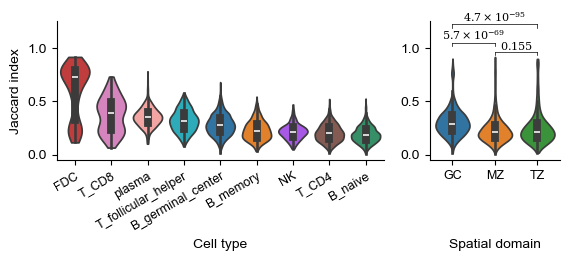

In [17]:
def e2latex(num):
    if num < 0.001:
        s = '{:.1e}'.format(num)
        s = s.replace('e', '\\times 10^{') + '}'
        return '$' + s + '$'
    else:
        return '$' + '{:.3f}'.format(num) + '$'

from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(6.5, 1.8))
gs = GridSpec(1, 3, width_ratios=[2.5, 0.0, 1], wspace=0.15, figure=fig)


axes2 = [fig.add_subplot(gs[0])]
axes3 = [fig.add_subplot(gs[2])]

ax = axes3[0]
sc.pl.violin(adata, keys='steamboat_nmf_jaccard', groupby='steamboat_region_labels', ax=ax, stripplot=False, show=False, inner="box")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, size=9)
ax.set_ylabel(None)
ax.set_xlabel('Spatial domain')
ax.set_ylim(-0.05, 1.25)
for pos in ['right', 'top']:
    ax.spines[pos].set_visible(False)

s, p = sp.stats.mannwhitneyu(adata.obs.loc[adata.obs['steamboat_region_labels'] == 'GC', 'steamboat_nmf_jaccard'],
                             adata.obs.loc[adata.obs['steamboat_region_labels'] == 'TZ', 'steamboat_nmf_jaccard'])
x = 0.5
w = 1
y = 1.05
h = 0.03
ax.text(x, y + 0.01, e2latex(p), 
        ha='center', va='bottom', fontsize=8)
ax.plot([x - w/2, x + w/2], [y]*2, color='black', lw=.5)
ax.plot([x - w/2, x - w/2], [y - h, y], color='black', lw=.5)
ax.plot([x + w/2, x + w/2], [y - h, y], color='black', lw=.5)

s, p = sp.stats.mannwhitneyu(adata.obs.loc[adata.obs['steamboat_region_labels'] == 'GC', 'steamboat_nmf_jaccard'],
                             adata.obs.loc[adata.obs['steamboat_region_labels'] == 'MZ', 'steamboat_nmf_jaccard'])
x = 1
w = 2
y = 1.22
h = 0.03
ax.text(x, y + 0.01, e2latex(p), 
        ha='center', va='bottom', fontsize=8)
ax.plot([x - w/2, x + w/2], [y]*2, color='black', lw=.5)
ax.plot([x - w/2, x - w/2], [y - h, y], color='black', lw=.5)
ax.plot([x + w/2, x + w/2], [y - h, y], color='black', lw=.5)

s, p = sp.stats.mannwhitneyu(adata.obs.loc[adata.obs['steamboat_region_labels'] == 'TZ', 'steamboat_nmf_jaccard'],
                             adata.obs.loc[adata.obs['steamboat_region_labels'] == 'MZ', 'steamboat_nmf_jaccard'])
x = 1.5
w = 1
y = 0.96
h = 0.03
ax.text(x, y + 0.01, e2latex(p),
        ha='center', va='bottom', fontsize=8)
ax.plot([x - w/2, x + w/2], [y]*2, color='black', lw=.5)
ax.plot([x - w/2, x - w/2], [y - h, y], color='black', lw=.5)
ax.plot([x + w/2, x + w/2], [y - h, y], color='black', lw=.5)

ax = axes2[0]

sc.pl.violin(adata, keys='steamboat_nmf_jaccard', groupby='cluster', 
             order=adata.obs.groupby('cluster')['steamboat_nmf_jaccard'].median().sort_values(ascending=False).index.tolist(), 
             ax=ax, stripplot=False, show=False, inner="box")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', rotation_mode='anchor', size=9)
ax.set_ylabel('Jaccard index')
ax.set_xlabel('Cell type')
ax.set_ylim(-0.05, 1.25)

for pos in ['right', 'top']:
    ax.spines[pos].set_visible(False)

fig.align_labels()

for pos in ['right', 'top']:
    ax.spines[pos].set_visible(False)
